# Three-Variable Keller-Segel Slime Mold Chemotaxis Simulation

Simulating *Dictyostelium* chemotaxis with separate **self-produced chemoattractant** (cAMP) and **external nutrient** using a three-variable Keller-Segel model with volume-filling, solved with the finite volume method (FiPy) on a 2D rectangular domain.

**Three Coupled PDEs:**
- Cell density: $\partial\rho/\partial t = D_\rho \nabla^2\rho - \chi(1 - \rho/\rho_{\max}) \nabla\cdot(\rho \nabla c) + \frac{\mu_{\max}}{Y} s \, \rho (1 - \rho/\rho_{\max})$
- cAMP chemoattractant (quasi-steady-state): $0 = D_c \nabla^2 c - \beta c + \alpha \rho$
- Nutrient/substrate (quasi-steady-state): $0 = D_s \nabla^2 s - \mu_{\max} s \, \rho$

**Key biological separation:**
- **cAMP (c)**: self-produced by cells (rate α), no-flux BCs — drives chemotactic aggregation via positive feedback
- **Nutrient (s)**: externally supplied at boundaries (Dirichlet BCs), consumed by cells — drives growth
- **Volume-filling** (Painter & Hillen 2002): chemotactic sensitivity → 0 as ρ → ρ_max, preventing blow-up

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from keller_segel import KellerSegelParams, run_simulation

## Parameter Configuration

All parameters in physical units: **mm** (space), **min** (time). Grid resolution dx = dy = 10 μm = one *Dictyostelium* cell length (BioNumbers: 9–12 μm).

| Parameter | Value | Units | Physical basis |
|-----------|-------|-------|----------------|
| `Lx, Ly` | 1.0 | mm | Aggregation territory |
| `nx, ny` | 100 | — | dx = dy = 0.01 mm = 10 μm |
| `D_rho` | 5×10⁻⁴ | mm²/min | ~50 μm²/min (v²τ/2, v~10 μm/min, τ~1 min) |
| `D_c` | 0.024 | mm²/min | cAMP diffusion (PMC2771350) |
| `D_s` | 0.012 | mm²/min | Nutrient diffusion (~half D_c) |
| `chi` | 0.015 | mm²/(min·conc) | Calibrated for ~4 μm/min chemotactic drift velocity |
| `beta` | 0.5 | min⁻¹ | PDE half-life ~1.4 min |
| `alpha` | 0.05 | conc/(min·density) | Sets steady-state cAMP ~ αρ/β |
| `mu_max` | 0.005 | min⁻¹ | Doubling time ~2–3 hours |
| `Y` | 0.5 | — | Yield coefficient |
| `rho_max` | 5.0 | normalized | Carrying capacity |
| `total_time` | 120 | min | 2-hour aggregation experiment |

Sources: cell length 9–12 μm (BioNumbers), cAMP diffusion 0.024 mm²/min (PMC2771350), cell speed 10–20 μm/min, chemotactic drift ~4 μm/min (RSC Soft Matter 2017).

In [14]:
params = KellerSegelParams(
    # Domain: 1mm x 1mm, 10 μm resolution
    Lx=1.0, Ly=1.0,
    nx=100, ny=100,
    # Cell dynamics (mm, min)
    D_rho=5e-4,          # random motility ~50 μm²/min
    chi=0.015,           # chemotactic sensitivity (~4 μm/min drift)
    mu_max=0.005,        # doubling time ~2-3 hrs
    Y=0.5,               # yield coefficient
    rho_max=5.0,         # carrying capacity
    # cAMP (mm²/min, min⁻¹)
    D_c=0.024,           # cAMP diffusion (literature)
    beta=0.5,            # PDE degradation, half-life ~1.4 min
    alpha=1.0,           # cAMP production rate (aggregation ratio ~6)
    # Nutrient (mm²/min)
    D_s=0.012,           # nutrient diffusion
    s_boundary=1.0,      # normalized nutrient at boundaries
    # Numerics (min)
    dt=0.1,              # 0.1 min timestep
    total_time=120.0,    # 2 hours
    sweep_count=3,
    snapshot_interval=12,
)

# Aggregation criterion: alpha * chi * rho_bg / (D_rho * beta) >> 1
agg_ratio = params.alpha * params.chi * params.rho_background / (params.D_rho * params.beta)
print(f"Domain: {params.Lx} x {params.Ly} mm, Mesh: {params.nx} x {params.ny}")
print(f"dx = {params.dx*1000:.0f} μm, dy = {params.dy*1000:.0f} μm")
print(f"Total steps: {params.n_steps}, Snapshots: ~{params.n_steps // params.snapshot_interval}")
print(f"Simulation time: {params.total_time:.0f} min = {params.total_time/60:.1f} hrs")
print(f"chi/D_rho ratio: {params.chi / params.D_rho:.1f}")
print(f"cAMP penetration length: {(params.D_c / params.beta)**0.5 * 1000:.0f} μm")
print(f"Aggregation ratio αχρ/(D_ρβ): {agg_ratio:.1f} (need >> 1)")

Domain: 1.0 x 1.0 mm, Mesh: 100 x 100
dx = 10 μm, dy = 10 μm
Total steps: 1200, Snapshots: ~100
Simulation time: 120 min = 2.0 hrs
chi/D_rho ratio: 30.0
cAMP penetration length: 219 μm
Aggregation ratio αχρ/(D_ρβ): 6.0 (need >> 1)


## Run Simulation

In [15]:
result = run_simulation(params, progbar=True)

print(f"\nSimulation complete.")
print(f"Snapshots saved: {len(result.times)}")
print(f"Final total mass: {result.total_mass[-1]:.4f}")
print(f"Final max density: {result.max_density[-1]:.4f}")

Keller-Segel:   0%|          | 0/1200 [00:00<?, ?step/s]


Simulation complete.
Snapshots saved: 101
Final total mass: 0.0964
Final max density: 33.3328


## Static Snapshots

Cell density (top, inferno), cAMP chemoattractant (middle, plasma), and nutrient concentration (bottom, viridis) at three timepoints.

/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_24384/398534451.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


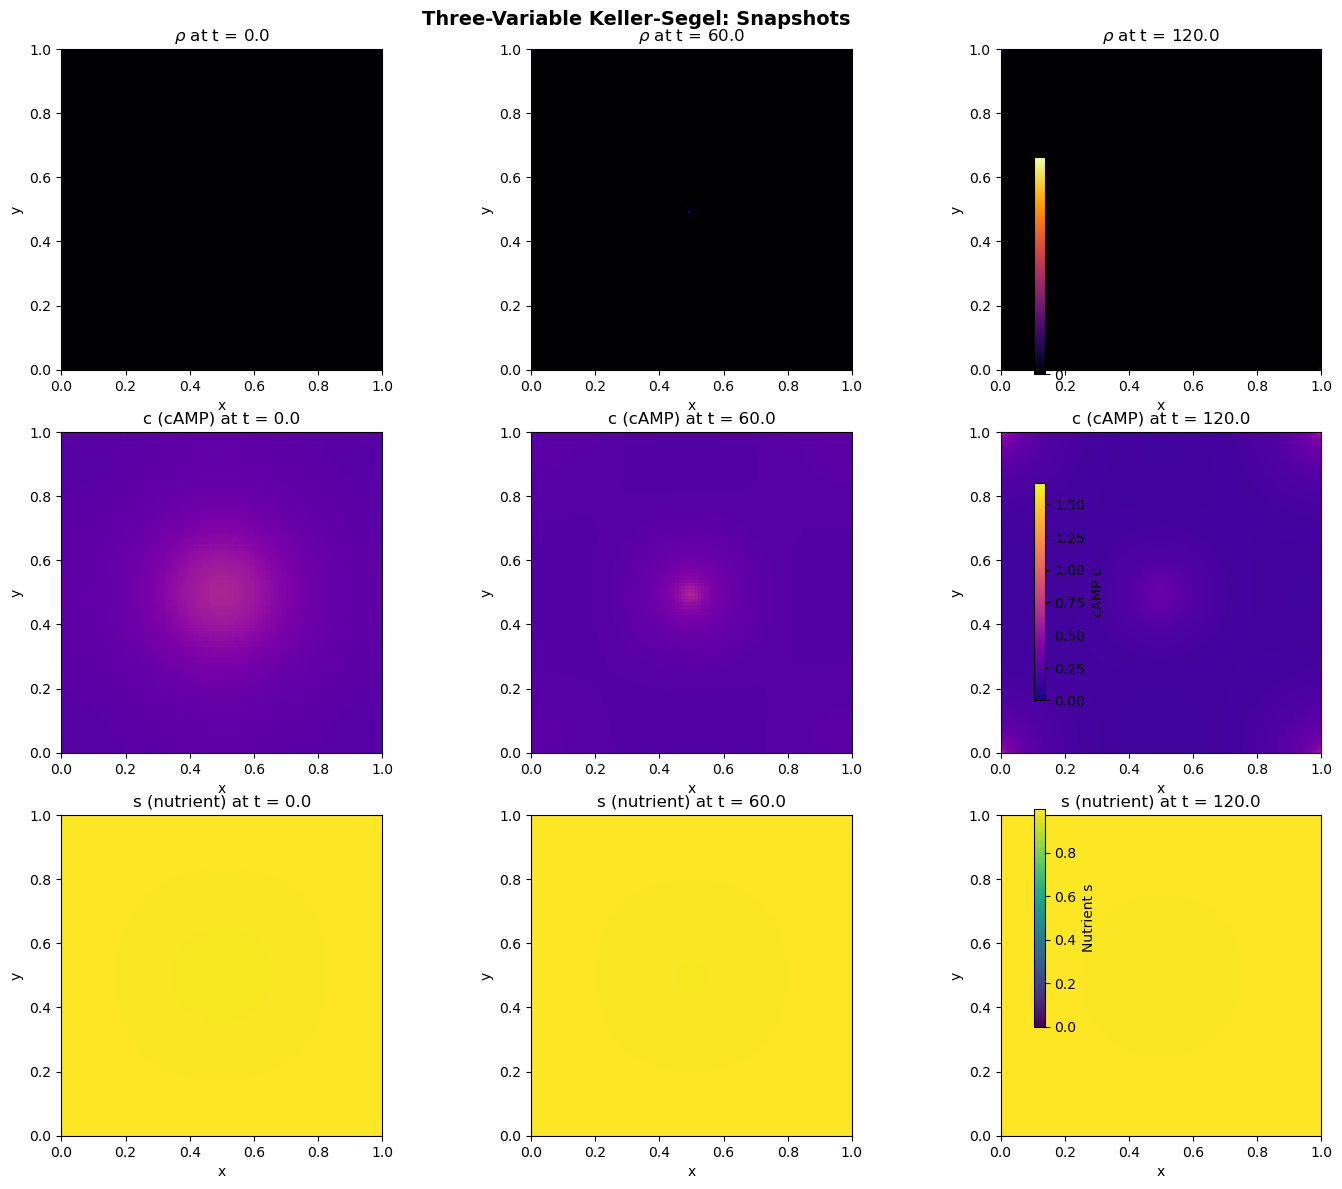

In [16]:
n_snapshots = len(result.times)
indices = [0, n_snapshots // 2, n_snapshots - 1]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

rho_vmax = max(snap.max() for snap in result.rho_snapshots)
c_vmax = max(snap.max() for snap in result.c_snapshots)
s_vmax = max(snap.max() for snap in result.s_snapshots)

for col, idx in enumerate(indices):
    t = result.times[idx]

    # Cell density
    im_rho = axes[0, col].imshow(
        result.rho_snapshots[idx],
        origin="lower",
        extent=[0, params.Lx, 0, params.Ly],
        cmap="inferno",
        vmin=0, vmax=rho_vmax,
    )
    axes[0, col].set_title(f"$\\rho$ at t = {t:.1f}")
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")

    # cAMP chemoattractant
    im_c = axes[1, col].imshow(
        result.c_snapshots[idx],
        origin="lower",
        extent=[0, params.Lx, 0, params.Ly],
        cmap="plasma",
        vmin=0, vmax=c_vmax,
    )
    axes[1, col].set_title(f"c (cAMP) at t = {t:.1f}")
    axes[1, col].set_xlabel("x")
    axes[1, col].set_ylabel("y")

    # Nutrient
    im_s = axes[2, col].imshow(
        result.s_snapshots[idx],
        origin="lower",
        extent=[0, params.Lx, 0, params.Ly],
        cmap="viridis",
        vmin=0, vmax=s_vmax,
    )
    axes[2, col].set_title(f"s (nutrient) at t = {t:.1f}")
    axes[2, col].set_xlabel("x")
    axes[2, col].set_ylabel("y")

fig.colorbar(im_rho, ax=axes[0, :], label="Cell density $\\rho$", shrink=0.8)
fig.colorbar(im_c, ax=axes[1, :], label="cAMP c", shrink=0.8)
fig.colorbar(im_s, ax=axes[2, :], label="Nutrient s", shrink=0.8)
fig.suptitle("Three-Variable Keller-Segel: Snapshots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("snapshots.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnostics: Total Mass and Max Density

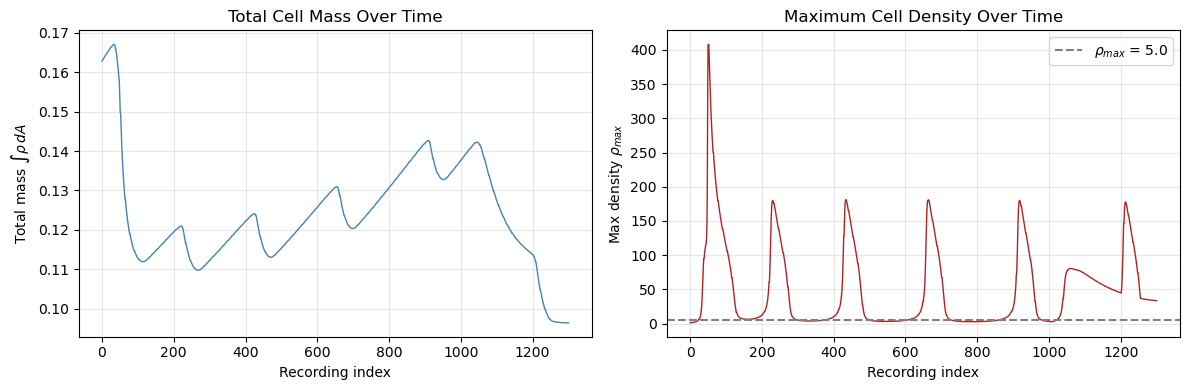

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Total mass includes both snapshot and per-step recordings
# Use per-step data for smooth plots
steps = np.arange(len(result.total_mass))

ax1.plot(steps, result.total_mass, color="steelblue", linewidth=1)
ax1.set_xlabel("Recording index")
ax1.set_ylabel("Total mass $\\int \\rho \, dA$")
ax1.set_title("Total Cell Mass Over Time")
ax1.grid(True, alpha=0.3)

ax2.plot(steps, result.max_density, color="firebrick", linewidth=1)
ax2.axhline(y=params.rho_max, color="gray", linestyle="--", label=f"$\\rho_{{max}}$ = {params.rho_max}")
ax2.set_xlabel("Recording index")
ax2.set_ylabel("Max density $\\rho_{max}$")
ax2.set_title("Maximum Cell Density Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Animation: Cell Density, cAMP, and Nutrient

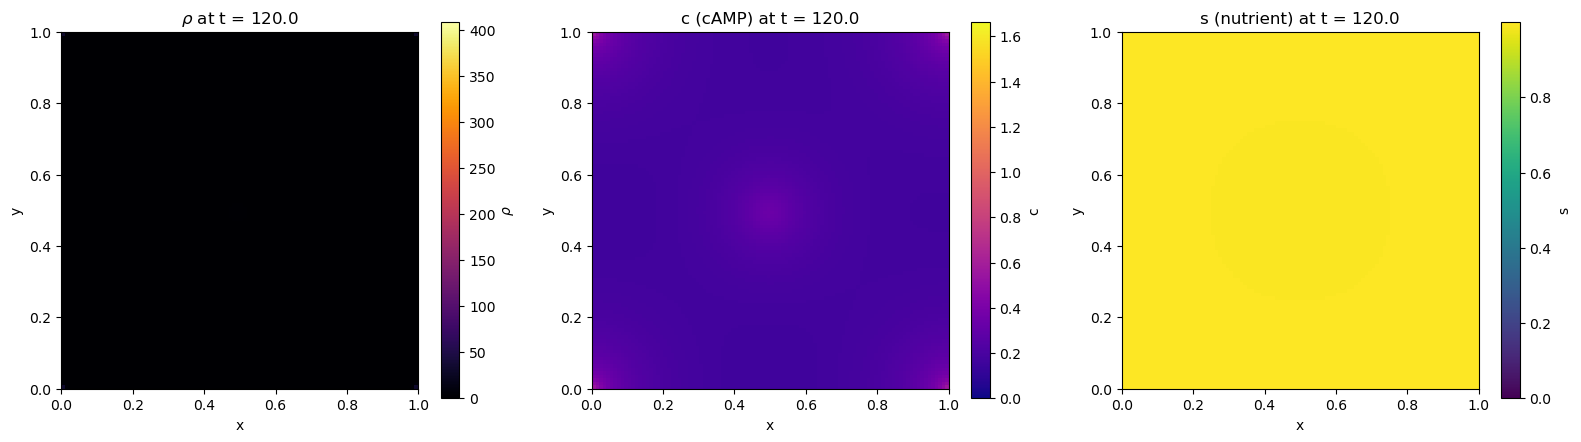

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

rho_vmax = max(snap.max() for snap in result.rho_snapshots)
c_vmax = max(snap.max() for snap in result.c_snapshots)
s_vmax = max(snap.max() for snap in result.s_snapshots)

im1 = ax1.imshow(
    result.rho_snapshots[0], origin="lower",
    extent=[0, params.Lx, 0, params.Ly],
    cmap="inferno", vmin=0, vmax=rho_vmax,
)
ax1.set_title(f"$\\rho$ at t = 0.0")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(im1, ax=ax1, label="$\\rho$", shrink=0.8)

im2 = ax2.imshow(
    result.c_snapshots[0], origin="lower",
    extent=[0, params.Lx, 0, params.Ly],
    cmap="plasma", vmin=0, vmax=c_vmax,
)
ax2.set_title(f"c (cAMP) at t = 0.0")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
fig.colorbar(im2, ax=ax2, label="c", shrink=0.8)

im3 = ax3.imshow(
    result.s_snapshots[0], origin="lower",
    extent=[0, params.Lx, 0, params.Ly],
    cmap="viridis", vmin=0, vmax=s_vmax,
)
ax3.set_title(f"s (nutrient) at t = 0.0")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
fig.colorbar(im3, ax=ax3, label="s", shrink=0.8)

plt.tight_layout()


def animate(frame):
    im1.set_data(result.rho_snapshots[frame])
    im2.set_data(result.c_snapshots[frame])
    im3.set_data(result.s_snapshots[frame])
    t = result.times[frame]
    ax1.set_title(f"$\\rho$ at t = {t:.1f}")
    ax2.set_title(f"c (cAMP) at t = {t:.1f}")
    ax3.set_title(f"s (nutrient) at t = {t:.1f}")
    return [im1, im2, im3]


anim = animation.FuncAnimation(
    fig, animate,
    frames=len(result.times),
    interval=200,
    blit=True,
)

HTML(anim.to_html5_video())

## Analysis

### Self-Organized Aggregation via cAMP Positive Feedback
The three-variable model captures the core *Dictyostelium* aggregation mechanism: cells **produce** cAMP (at rate α), which diffuses locally and is degraded by phosphodiesterase (rate β). Where cells cluster, cAMP concentration rises, creating a gradient that attracts more cells via chemotaxis (χ∇c). This positive feedback loop drives self-organized aggregation — cells move toward each other, not toward boundaries.

### Nutrient Depletion as Growth Limiter
Nutrient (s) is supplied at the domain boundaries (Dirichlet BCs) and consumed by cells at rate μ_max·s·ρ. Where cells are dense, nutrient is depleted locally, reducing the growth rate. This creates a natural growth ceiling: total mass increases initially but plateaus as nutrient limitation kicks in. The logistic cap (1 - ρ/ρ_max) provides an additional safety bound.

### Separation of Chemotaxis and Growth Roles
Unlike the previous two-variable model where cells consumed the same signal they were chasing (destroying the gradient driving movement), here:
- **cAMP (c)** drives chemotaxis only — self-produced, no-flux BCs, not consumed
- **Nutrient (s)** drives growth only — externally supplied, Dirichlet BCs, consumed by cells

This separation is biologically correct: in real *Dictyostelium*, cAMP is a self-produced signaling molecule while nutrients (bacteria, folate) are separate external substrates.

### Tokyo Metro Connection
The model is now architecturally ready for the Physarum/Tokyo Metro experiment: food sources can be placed at specific boundary locations via the per-edge `s_boundary` dict (e.g., `{"left": 1.0, "right": 1.0, "top": 0.0, "bottom": 0.0}`), and cells will self-organize transport paths between them via cAMP-mediated aggregation — analogous to how *Physarum* forms efficient networks between food sources.

### Conservation and Stability
- **Total mass** is not conserved (growth term adds biomass) but is self-limiting via nutrient depletion and logistic saturation
- **cAMP field** peaks where cells cluster (self-produced) — opposite of the old model where it was depleted by cells
- **Nutrient field** shows depletion where cells are dense (consumed) — supplied from boundaries
- The `ExponentialConvectionTerm` (Scharfetter-Gummel scheme) remains critical for stability when the Peclet number Pe = χ|∇c|Δx/D_ρ is large